In [18]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [19]:
# angle data
angles_df_backward = pd.read_csv('angles_df_backward.csv')
angles_df_forward = pd.read_csv('angles_df_forward.csv')

In [20]:
color_red = '#E89DA0'
color_blue = '#88CEE6'

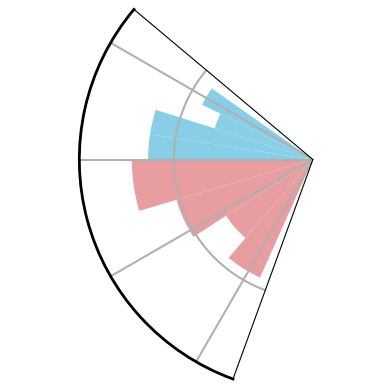

In [21]:
# plot polar plot
polar_plot_1 = np.radians(angles_df_forward['Angle_before_entry'])
polar_plot_2 = np.radians(angles_df_forward['Angle_after_entry'])

# Create a polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

bin_num_1 = 4
bin_num_2 = 4
max_before = max(polar_plot_1.max(), np.pi-polar_plot_2.max())
bin_edges_1 = np.linspace(0, max_before, bin_num_1+1)
# change bin_edges_1
bin_edges_1 = np.linspace(0, max_before-0.01, bin_num_1+1)
min_after = min(np.pi-max_before, polar_plot_2.min())
bin_edges_2 = np.linspace(min_after+0.1, np.pi, bin_num_2+1)

#---normalize histogram to sum=1---
# Compute histograms manually
counts_before, _ = np.histogram(polar_plot_1, bins=bin_edges_1)
counts_after, _ = np.histogram(polar_plot_2, bins=bin_edges_2)

# Normalize so that the sum of each bar is 1
counts_before = counts_before / counts_before.sum()
counts_after = counts_after / counts_after.sum()

# Compute bin centers for plotting
bin_centers_1 = 0.5 * (bin_edges_1[:-1] + bin_edges_1[1:])
bin_centers_2 = 0.5 * (bin_edges_2[:-1] + bin_edges_2[1:])

# Plot bars manually
ax.bar(bin_centers_1, counts_before, width=np.diff(bin_edges_1), alpha=1, label="Entry Angle", color=color_blue)
ax.bar(bin_centers_2, counts_after, width=np.diff(bin_edges_2)
        , alpha=1, label="Post-Entry Angle", color=color_blue)
#------
       

# Labels and legend
# ax.set_theta_zero_location("E")  # Set 0° to the right (east)
ax.set_theta_zero_location("W")  # Set 0° to the top (north)
ax.set_theta_direction(-1)  # Set direction to counterclockwise
# ax.legend()

# ----backward-----
# plot polar plot
polar_plot_1 = np.radians(angles_df_backward['Angle_before_entry'])
polar_plot_2 = np.radians(angles_df_backward['Angle_after_entry'])

bin_num_1 = 4
bin_num_2 = 4
max_before = max(polar_plot_1.max(), np.pi-polar_plot_2.max())
bin_edges_1 = np.linspace(0, max_before, bin_num_1+1)
min_after = max(np.pi-max_before, polar_plot_2.min())
bin_edges_2 = np.linspace(min_after+0.1, np.pi, bin_num_2+1)

#---normalize histogram to sum=1---
# Compute histograms manually
counts_before, _ = np.histogram(polar_plot_1, bins=bin_edges_1)
counts_after, _ = np.histogram(polar_plot_2, bins=bin_edges_2)

# Normalize so that the sum of each bar is 1
counts_before = counts_before / counts_before.sum()
counts_after = counts_after / counts_after.sum()

# Compute bin centers for plotting
bin_centers_1 = 0.5 * (bin_edges_1[:-1] + bin_edges_1[1:])
bin_centers_2 = 0.5 * (bin_edges_2[:-1] + bin_edges_2[1:])

# Plot bars manually
ax.bar(-bin_centers_1, counts_before, width=np.diff(bin_edges_1), alpha=1, label="Before Entry", color=color_red)
ax.bar(-bin_centers_2, counts_after, width=np.diff(bin_edges_2)
        , alpha=1, label="Post-Entry Angle", color=color_red)


ax.set_yticks([0, 0.25])  # Less radial ticks
# no tick label
ax.set_yticklabels([])  # Remove radial tick labels
ax.set_ylim(0, 0.42) # fix this
# show degrees
degree_lim = 70
# ax.set_thetalim(-np.pi*degree_lim/180, np.pi*degree_lim/180) # left part
ax.set_thetalim(-np.pi*degree_lim/180, np.pi*40/180) # left part
# ax.set_thetalim(-np.pi, np.pi) # full part

# ticks: -pi/3: 60, -pi/6: 30, 0: 0, pi/6: 30, pi/3: 60
# ax.set_xticks([-1*np.pi/3, -1*np.pi/6, 0, np.pi/6, np.pi/3])  # left part, equal
ax.set_xticks([-1*np.pi/3, -1*np.pi/6, 0, np.pi/6])  # left part, non equal

ax.set_xticklabels([])  # Remove angular tick labels

# set axis thickness
ax.spines['polar'].set_linewidth(2)  # Set the thickness of the polar axis line

# # ---set box size---
# def set_size(w,h, ax=None):
#     """ w, h: width, height in inches """
#     if not ax: ax=plt.gca()
#     l = ax.figure.subplotpars.left
#     r = ax.figure.subplotpars.right
#     t = ax.figure.subplotpars.top
#     b = ax.figure.subplotpars.bottom
#     figw = float(w)/(r-l)
#     figh = float(h)/(t-b)
#     ax.figure.set_size_inches(figw, figh)

# set_size(8, 5)

# set grid thickness
ax.yaxis.grid(True, linewidth=1.5)  # Set the thickness of the grid lines
ax.xaxis.grid(True, linewidth=1.5)  # Set the thickness of the grid lines


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Combined Entry Angle-polar plot_left_equal.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
# plt.savefig('Combined Entry Angle-polar plot_left_nonequal.png', format='png', dpi=900, transparent=True, bbox_inches='tight')



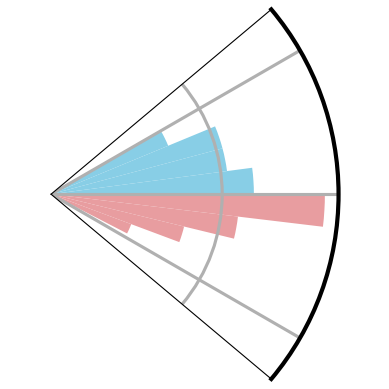

In [22]:
# plot polar plot
polar_plot_1 = np.radians(angles_df_forward['Angle_before_entry'])
polar_plot_2 = np.radians(angles_df_forward['Angle_after_entry'])

# Create a polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

bin_num_1 = 4
bin_num_2 = 4
max_before = max(polar_plot_1.max(), np.pi-polar_plot_2.max())
bin_edges_1 = np.linspace(0, max_before, bin_num_1+1)
# change bin_edges_1
bin_edges_1 = np.linspace(0, max_before-0.01, bin_num_1+1)
min_after = min(np.pi-max_before, polar_plot_2.min())
bin_edges_2 = np.linspace(min_after+0.1, np.pi, bin_num_2+1)

#---normalize histogram to sum=1---
# Compute histograms manually
counts_before, _ = np.histogram(polar_plot_1, bins=bin_edges_1)
counts_after, _ = np.histogram(polar_plot_2, bins=bin_edges_2)

# Normalize so that the sum of each bar is 1
counts_before = counts_before / counts_before.sum()
counts_after = counts_after / counts_after.sum()

# Compute bin centers for plotting
bin_centers_1 = 0.5 * (bin_edges_1[:-1] + bin_edges_1[1:])
bin_centers_2 = 0.5 * (bin_edges_2[:-1] + bin_edges_2[1:])

# Plot bars manually
# ax.bar(bin_centers_1, counts_before, width=np.diff(bin_edges_1), alpha=1, label="Entry Angle", color=color_blue)
ax.bar(np.pi-bin_centers_2, counts_after, width=np.diff(bin_edges_2)
        , alpha=1, label="Post-Entry Angle", color=color_blue)
#------
       

# Labels and legend
# ax.set_theta_zero_location("E")  # Set 0° to the right (east)
ax.set_theta_zero_location("E")  # Set 0° to the top (north)
ax.set_theta_direction(1)  # Set direction to counterclockwise
# ax.legend()

# ----backward-----
# plot polar plot
polar_plot_1 = np.radians(angles_df_backward['Angle_before_entry'])
polar_plot_2 = np.radians(angles_df_backward['Angle_after_entry'])

bin_num_1 = 4
bin_num_2 = 4
max_before = max(polar_plot_1.max(), np.pi-polar_plot_2.max())
bin_edges_1 = np.linspace(0, max_before, bin_num_1+1)
min_after = max(np.pi-max_before, polar_plot_2.min())
bin_edges_2 = np.linspace(min_after+0.1, np.pi, bin_num_2+1)

#---normalize histogram to sum=1---
# Compute histograms manually
counts_before, _ = np.histogram(polar_plot_1, bins=bin_edges_1)
counts_after, _ = np.histogram(polar_plot_2, bins=bin_edges_2)

# Normalize so that the sum of each bar is 1
counts_before = counts_before / counts_before.sum()
counts_after = counts_after / counts_after.sum()

# Compute bin centers for plotting
bin_centers_1 = 0.5 * (bin_edges_1[:-1] + bin_edges_1[1:])
bin_centers_2 = 0.5 * (bin_edges_2[:-1] + bin_edges_2[1:])

# Plot bars manually
# ax.bar(-bin_centers_1, counts_before, width=np.diff(bin_edges_1), alpha=1, label="Before Entry", color=color_red)
ax.bar(-np.pi+bin_centers_2, counts_after, width=np.diff(bin_edges_2)
        , alpha=1, label="Post-Entry Angle", color=color_red)


ax.set_yticks([0, 0.25])  # Less radial ticks
# no tick label
ax.set_yticklabels([])  # Remove radial tick labels
ax.set_ylim(0, 0.42) # fix this
# show degrees
degree_lim = 70
# ax.set_thetalim(-np.pi*degree_lim/180, np.pi*degree_lim/180) # right part, equal
ax.set_thetalim(-np.pi*40/180, np.pi*40/180) # right part, nonequal
# ax.set_thetalim(-np.pi, np.pi) # full part

# ticks: -pi/3: 60, -pi/6: 30, 0: 0, pi/6: 30, pi/3: 60
# ax.set_xticks([-1*np.pi/3, -1*np.pi/6, 0, np.pi/6, np.pi/3])  # equal
ax.set_xticks([ -1*np.pi/6, 0, np.pi/6])  # nonequal 
ax.set_xticklabels([])  # Remove angular tick labels

# set axis thickness
ax.spines['polar'].set_linewidth(2)  # Set the thickness of the polar axis line

# # ---set box size---
# def set_size(w,h, ax=None):
#     """ w, h: width, height in inches """
#     if not ax: ax=plt.gca()
#     l = ax.figure.subplotpars.left
#     r = ax.figure.subplotpars.right
#     t = ax.figure.subplotpars.top
#     b = ax.figure.subplotpars.bottom
#     figw = float(w)/(r-l)
#     figh = float(h)/(t-b)
#     ax.figure.set_size_inches(figw, figh)

# set_size(8, 5)

# set grid thickness
ax.yaxis.grid(True, linewidth=1.5)  # Set the thickness of the grid lines
ax.xaxis.grid(True, linewidth=1.5)  # Set the thickness of the grid lines

# ---thickness for noneuqal---
# 150pt/103pt
ax.yaxis.grid(True, linewidth=1.5*1.5)
ax.xaxis.grid(True, linewidth=1.5*1.5)
ax.spines['polar'].set_linewidth(2*1.5) 



# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Combined Entry Angle-polar plot_right_equal.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
# plt.savefig('Combined Entry Angle-polar plot_right_nonequal.png', format='png', dpi=900, transparent=True, bbox_inches='tight')


